# Optimal Transport in linear ICA

#### In this notebook we test the performance of a OT Natural Gradient ICA versus Fast ICA over dimensions.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import FastICA
from tqdm.notebook import tqdm

# Import your package
from wasserstein_ica import WassersteinICA

In [2]:
# ==========================================
# 1. Helpers & Data Generation
# ==========================================

def amari_error(W_est, A_true):
    if W_est is None or np.any(np.isnan(W_est)):
        return np.nan
        
    P = np.abs(W_est @ A_true)
    n = P.shape[0]
    
    row_sum = np.sum(P, axis=1)
    row_max = np.max(P, axis=1)
    term1 = np.sum((row_sum / row_max) - 1)
    
    col_sum = np.sum(P, axis=0)
    col_max = np.max(P, axis=0)
    term2 = np.sum((col_sum / col_max) - 1)
    
    return (term1 + term2) / (2 * n)

def generate_dataset(n_dim, n_samples, seed=None):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    # Standard Laplace (Super-Gaussian)
    sources = [np.random.laplace(0, 1, n_samples) for _ in range(n_dim)]
    S = np.stack(sources)
    
    # Well-conditioned mixing matrix
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return torch.tensor(X, dtype=torch.float32), A

In [3]:
# ==========================================
# 2. Experiment Setup
# ==========================================

# Test a range of dimensions up to 30
DIMENSIONS = [n for n in range(5, 51, 5)]  # Varying D
N_SAMPLES = 5000
N_TRIALS = 5  # Run multiple trials for error bars

print(f"--- FastICA vs. OT Fixed-Point Showdown ---")
print(f"Dimensions: {DIMENSIONS}")
print(f"Samples: {N_SAMPLES}")
print(f"Trials per dim: {N_TRIALS}")

results = []

--- FastICA vs. OT Fixed-Point Showdown ---
Dimensions: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
Samples: 5000
Trials per dim: 5


In [4]:
# ==========================================
# 3. Main Loop
# ==========================================

for dim in tqdm(DIMENSIONS, desc="Dimensions"):
    for trial in range(N_TRIALS):
        # 1. Generate Data
        X_torch, A_true = generate_dataset(n_dim=dim, n_samples=N_SAMPLES, seed=trial)
        X_np = X_torch.numpy()
        
        # 2. FastICA (Baseline)
        try:
            fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-4, random_state=trial)
            fast_ica.fit(X_np.T)
            W_fast_total = fast_ica.components_
            score_fast = amari_error(W_fast_total, A_true)
        except Exception as e:
            score_fast = np.nan
            W_fast_total = None
            
        results.append({'Dimension': dim, 'Method': 'FastICA', 'Amari Error': score_fast})
        
        # 3. Initialize WassersteinICA
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        # 4. Wasserstein Fixed-Point (Cold Start - Random)
        try:
            # We don't pass init_w, so it starts random
            W_sphere_cold = ica.optimize_fixed_point(n_components=dim, max_iter=100, tol=1e-5)
            W_wass_cold_total = W_sphere_cold.cpu().numpy() @ W_white_np
            score_cold = amari_error(W_wass_cold_total, A_true)
        except Exception as e:
            score_cold = np.nan
            
        results.append({'Dimension': dim, 'Method': 'W-ICA (Cold Start)', 'Amari Error': score_cold})
        
        # 5. Standalone WassersteinICA (Phase 1 + Natural Gradient Polish)
        try:
            # PHASE 1: Robust Deflation (Find the mountains)
            extracted_ws = []
            for _ in range(dim):
                prev = torch.stack(extracted_ws) if extracted_ws else None
                # Using 50 restarts to guarantee we avoid local minima
                w, _ = ica.optimize_wasserstein2(prev_components=prev, max_iter=200, n_restarts=50)
                extracted_ws.append(w)
            W_deflation_init = torch.stack(extracted_ws)
            
            # PHASE 2: Natural Gradient Polish over GL(n)
            # We feed the Phase 1 output into optimize_symmetric using the 'natural' optimizer
            W_natural_unmixed = ica.optimize_symmetric(
                n_components=dim, 
                max_iter=200, 
                lr=0.5, # Slightly lower learning rate recommended for stability in GL(n)
                init_w=W_deflation_init, 
                optimizer='natural',
                penalty_weight=1.0 # Controls the log|det W| volume-preserving penalty
            )
            
            # CRITICAL ADDITION: Because Natural Gradient optimizes over the non-orthogonal 
            # General Linear Group GL(n), we must symmetrically orthogonalize it ONE FINAL TIME 
            # before calculating the Amari error against the whitened data space.
            W_final_orthogonal = ica._symmetric_decorrelation(W_natural_unmixed)
            
            W_wass_total = W_final_orthogonal.cpu().numpy() @ W_white_np
            score_wass = amari_error(W_wass_total, A_true)
        except Exception as e:
            print(f"Failed at dim {dim}: {e}")
            score_wass = np.nan
            
        results.append({'Dimension': dim, 'Method': 'W-ICA (Natural Gradient)', 'Amari Error': score_wass})

Dimensions:   0%|          | 0/10 [00:00<?, ?it/s]

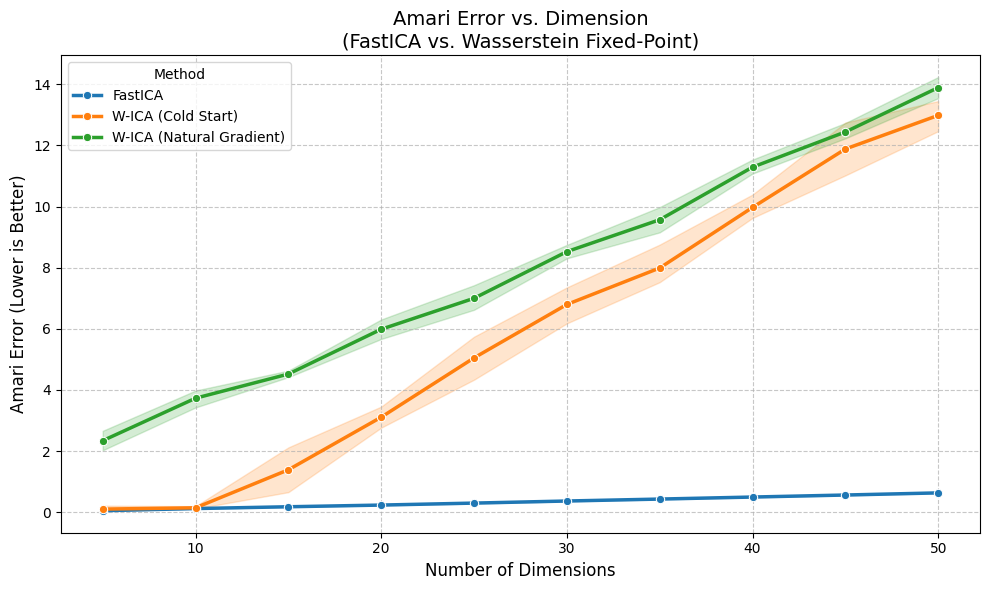

Method,FastICA,W-ICA (Cold Start),W-ICA (Natural Gradient)
Dimension,,,
5,0.0482,0.1003,2.3385
10,0.1183,0.1428,3.7281
15,0.1771,1.3867,4.5186
20,0.2324,3.1077,5.9845
25,0.2971,5.0471,6.9972
30,0.3653,6.7954,8.5238
35,0.4287,7.9887,9.5671
40,0.4952,9.9702,11.2877
45,0.5612,11.8817,12.4396


In [5]:
df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
# seaborn's lineplot automatically plots the mean and a confidence interval for the trials
sns.lineplot(data=df, x='Dimension', y='Amari Error', hue='Method', marker='o', linewidth=2.5)

plt.title("Amari Error vs. Dimension\n(FastICA vs. Wasserstein Fixed-Point)", fontsize=14)
plt.ylabel("Amari Error (Lower is Better)", fontsize=12)
plt.xlabel("Number of Dimensions", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
#plt.yscale('log') # Log scale is often better for Amari Error to see small polish improvements
plt.tight_layout()
plt.show()

# Display mean scores table
display(df.groupby(['Dimension', 'Method'])['Amari Error'].mean().unstack().round(4))